## Problem Overview

The goal of this project is to predict daily sales for Rossmann stores using historical store-level sales records and additional store metadata. This is a supervised machine learning regression problem because the target variable, Sales, is a continuous numerical value, and the model is trained using past observations where the true sales values are already known.

Accurate sales forecasting is an important business task in retail. Reliable predictions can help companies improve inventory management, staff scheduling, promotion planning, and financial decision-making. If future sales are underestimated, stores may run out of stock and lose revenue. If they are overestimated, stores may overstock products and increase operational costs. For this reason, building a strong sales forecasting model has direct practical value.

The Rossmann dataset combines two important sources of information. The first contains daily operational data for each store, including variables such as the date, whether the store was open, whether a promotion was active, the day of the week, holidays, and the number of customers. The second contains store-level attributes, such as store type, assortment type, competition distance, and long-term promotion program information. By combining these two datasets, we can better understand both the short-term and structural factors that influence sales.

This problem is challenging because sales depend on many interacting factors. They vary across time due to seasonality, weekdays, weekends, holidays, and promotional events, and they also vary across stores because different stores have different formats, assortments, and competitive environments. In addition, some variables contain missing values, which makes data preprocessing and feature engineering essential parts of the project.

The overall objective of this notebook is to build an end-to-end machine learning pipeline that can learn the relationship between these variables and store sales, compare different regression models, evaluate their performance using suitable error metrics, and finally generate predictions for unseen test data. In this way, the project demonstrates how machine learning can be used to solve a real-world retail forecasting problem.

## Features Overview

To make the dataset easier to understand, we first examine the three provided files: **`train.csv`**, which contains historical daily sales records; **`test.csv`**, which contains the unseen observations for which sales must be predicted; and **`store.csv`**, which provides additional store-level information that can be merged using the `Store` column.


---

## `train` Features

| Column | Type | Description | Role in Modeling |
|---|---|---|---|
| **Store** | Categorical / ID | Unique identifier for each store. | Helps the model distinguish between stores with different sales patterns. |
| **DayOfWeek** | Numerical / Categorical | Day of the week for the observation. | Captures weekly sales patterns such as weekday and weekend behavior. |
| **Date** | Date | Calendar date of the record. | Can be transformed into year, month, day, and seasonal features. |
| **Sales** | Numerical | Total daily sales for the store. | **Target variable** to be predicted. |
| **Customers** | Numerical | Number of customers who visited the store that day. | Strongly related to sales, although it may not always be available for future prediction. |
| **Open** | Binary | Indicates whether the store was open (`1`) or closed (`0`). | Important because closed stores usually have zero or near-zero sales. |
| **Promo** | Binary | Indicates whether a short-term promotion was running that day. | Helps capture the sales impact of promotions. |
| **StateHoliday** | Categorical | Indicates whether the day was a public or state holiday. | Useful because holidays can significantly affect customer traffic and sales. |
| **SchoolHoliday** | Binary | Indicates whether schools were closed that day. | Can influence shopping behavior, especially for families. |

---

## `store` Features

| Column | Type | Description | Role in Modeling |
|---|---|---|---|
| **Store** | Categorical / ID | Unique identifier for each store. Used to merge with `train` or `test`. | Connects store-level information to daily sales records. |
| **StoreType** | Categorical | Category of store model (`a`, `b`, `c`, `d`). | Helps explain structural differences in sales across store formats. |
| **Assortment** | Categorical | Assortment level of the store: `a` = basic, `b` = extra, `c` = extended. | Indicates how broad the product selection is, which may affect sales volume. |
| **CompetitionDistance** | Numerical | Distance in meters to the nearest competitor store. | Reflects local competitive pressure. |
| **CompetitionOpenSinceMonth** | Numerical | Approximate month when the nearest competitor opened. | Helps estimate how long competitive pressure has existed. |
| **CompetitionOpenSinceYear** | Numerical | Approximate year when the nearest competitor opened. | Works with the month column to measure competition timing. |
| **Promo2** | Binary | Indicates whether the store participates in a continuous recurring promotion program (`0` = no, `1` = yes). | Captures long-term promotional strategy. |
| **Promo2SinceWeek** | Numerical | Calendar week when the store started participating in `Promo2`. | Gives timing information for recurring promotions. |
| **Promo2SinceYear** | Numerical | Year when the store started participating in `Promo2`. | Helps measure how long the recurring promotion has been active. |
| **PromoInterval** | Categorical | Months when `Promo2` restarts in each cycle, for example `"Feb,May,Aug,Nov"`. | Describes the recurring schedule of long-term promotions. |

---

## Why These Features Matter

These variables help explain sales from multiple perspectives. The daily features describe what was happening on a specific date, such as whether the store was open, whether a promotion was active, and whether the day was a holiday. The store-level features describe the broader business environment, including store format, assortment, nearby competition, and long-running promotional programs. Together, they allow the model to learn both short-term sales drivers and long-term structural patterns.

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Loading the Dataset

In [2]:
DATA_PATH = Path("train.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}."
    )


In [3]:
df = pd.read_csv(DATA_PATH, dtype={"StateHoliday": "string"})
print(f"Shape: {df.shape}")
df.head()

Shape: (1017209, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  string
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), str(1), string(1)
memory usage: 80.5 MB


## Exploratory Data Analysis (EDA)

Before building machine learning models, it is important to explore the dataset and understand its main patterns. Exploratory Data Analysis helps reveal the structure of the data, the distribution of important variables, relationships between features, and potential issues such as missing values, skewness, or outliers.

In this section, we examine the sales data through summary statistics and visualizations to better understand how sales vary across time, stores, promotions, and other factors. These insights help guide preprocessing, feature engineering, and model selection in the later stages of the project.

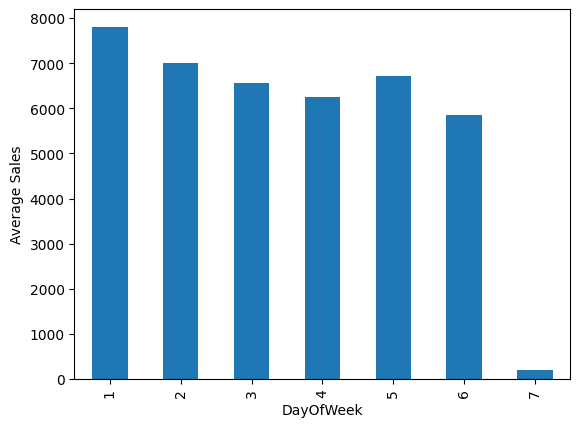

In [5]:
day_sales = df.groupby('DayOfWeek')['Sales'].mean()
day_sales.plot(kind='bar')
plt.ylabel('Average Sales')
plt.show()

This bar chart presents the average sales for each day of the week. The results show that sales are not evenly distributed across the week, as some days have noticeably higher average sales than others. In particular, day 1 records the highest average sales, while day 7 shows extremely low average sales compared with the other days, which likely indicates that many stores are closed or have very limited activity on that day.

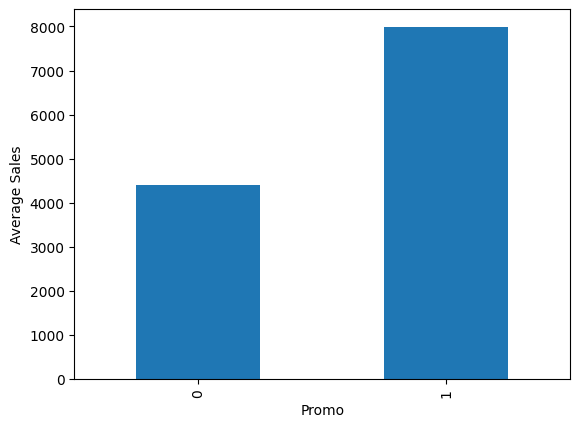

In [6]:
promo_sales = df.groupby('Promo')['Sales'].mean()
promo_sales.plot(kind='bar')
plt.ylabel('Average Sales')
plt.show()

This chart compares the average sales on days without a promotion and days with a promotion. The result shows that average sales are much higher when a promotion is active. Stores with `Promo = 1` have noticeably greater average sales than stores with `Promo = 0`, indicating a clear difference in customer purchasing behavior during promotional periods.

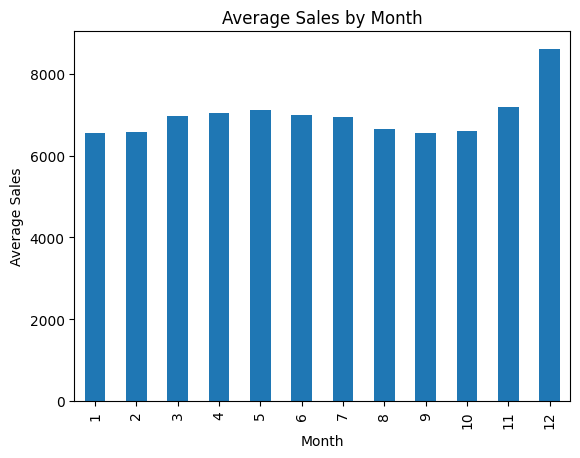

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

month_sales = df[df['Open'] == 1].groupby('Month')['Sales'].mean()
month_sales.plot(kind='bar')
plt.ylabel('Average Sales')
plt.title('Average Sales by Month')
plt.show()

This chart shows the **average sales for each month**, considering only days when stores were open. The results suggest that sales vary across the year, indicating a seasonal pattern in customer activity. Average sales remain fairly stable in many months, but they increase noticeably toward the end of the year, with **December showing the highest average sales**. This may reflect stronger consumer demand during the holiday season.

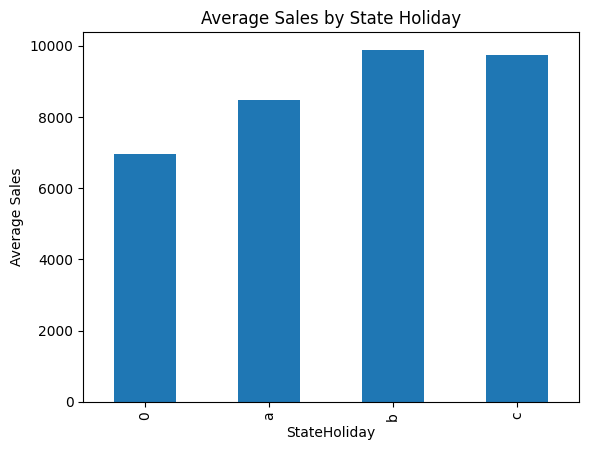

In [8]:
holiday_sales = df[df['Open'] == 1].groupby('StateHoliday')['Sales'].mean()
holiday_sales.plot(kind='bar')
plt.ylabel('Average Sales')
plt.title('Average Sales by State Holiday')
plt.show()

This chart shows the **average sales by state holiday category**, using only days when stores were open. The results indicate that sales differ across holiday types rather than remaining constant. Stores recorded the lowest average sales on regular non-holiday days (`0`), while higher averages appear for the holiday categories `a`, `b`, and `c`. This suggests that different holiday periods are associated with noticeable changes in sales levels.

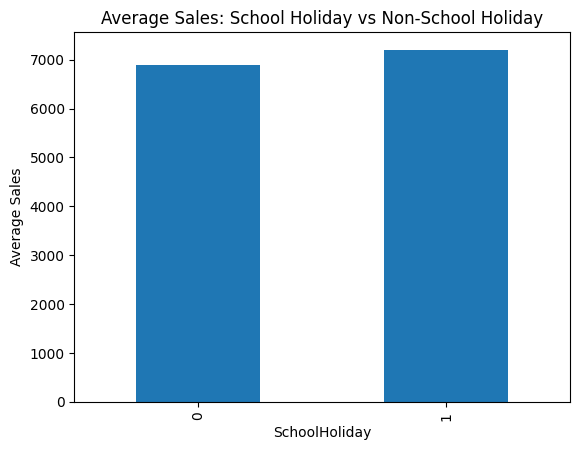

In [9]:
school_sales = df[df['Open'] == 1].groupby('SchoolHoliday')['Sales'].mean()
school_sales.plot(kind='bar')
plt.ylabel('Average Sales')
plt.title('Average Sales: School Holiday vs Non-School Holiday')
plt.show()

This chart compares the **average sales on school holiday days and non-school holiday days**, considering only days when stores were open. The difference between the two groups is relatively small, but average sales are slightly higher during school holidays. This suggests that school holiday periods may have a modest influence on customer activity and sales.